## Modeling

In this notebook, we build a baseline linear regression model to predict insurance charges and test whether an interaction effect (BMI x smoker) improves performance.

## 1. Regression Modeling

After exploring relationships visually and quantitatively through correlation analysis, we now move to predictive modeling.

The objective is to quantify the impact of key variables on insurance charges and assess how well they explain the variability in costs.

We begin with a baseline linear regression model using the most relevant predictors identified during exploratory analysis:
- Age
- BMI
- Number of children
- smoking status

This will allow us to:
- Measure the strength of each predictor
- Compare their relative influence
- Evaluate overall model performance using R²

### 1.1 Baseline Linear Regression

In [6]:
import pandas as pd
df = pd.read_csv("../data/processed/insurance_clean.csv")
df["smoker_encoded"] = df["smoker"].map({"no": 0, "yes": 1})
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Define features and target variable
x = df[["age", "bmi", "children", "smoker_encoded"]]
y = df["charges"]

# 2. Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Train the linear regression model
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [8]:
r2 = model.score(x_test, y_test)
r2

0.8045531086669289

In [9]:
coefficients = pd.DataFrame({"Feature": x_train.columns, "Coefficient": model.coef_})
coefficients

,Feature,Coefficient
0,age,249.191292
1,bmi,305.267404
2,children,537.972196
3,smoker_encoded,23042.507238


### 1.2 Interpretation of the Baseline Model

The baseline linear regression model explainsaproximately 80% of the variance in insurance charges (R² ~ 0.80), indicating strong predictive performance.

Smoking status is by far the most influential predictor. Being a smoker increases expected insurance charges by aproximately 23,000 units, holding other variables constant.

Age and BMI both show positive effects on charges. Each additional year of age increases expected costs by roughly 249 units, while each additional BMI unit increases costs by about 305 units.

The number of children also shows a positive effect (~ 538 per additional child), although earlier exploratory analysis suggested that its overall influence is relatively small compared to smoking status.

Overall, the model confirms that lifestyle-related factors, particularly smoking, dominate the cost structure.

### 1.3 Adding Interaction Term (BMI x Smoker)

In [10]:
df["bmi_smoker_interaction"] = df["bmi"] * df["smoker_encoded"]

In [11]:
x_int = df[["age", "bmi", "children", "smoker_encoded", "bmi_smoker_interaction"]]
y = df["charges"]

In [12]:
x_train_i, x_test_i, y_train_i, y_test_i = train_test_split(x_int, y, test_size=0.2, random_state=42)

In [13]:
model_i = LinearRegression()
model_i.fit(x_train_i, y_train_i)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
r2_i = model_i.score(x_test_i, y_test_i)
r2_i

0.8833784420416602

### Interaction Effect: BMI x Smoking

Adding an interaction term between BMI and smoking status significantly improved the model performance.

R² increased from aproximately 0.80 to 0.88, indicating that BMI has a stronger impact on insurance charges among smokers.

This confirms the presence of a conditional effect and highlights the importance of modeling interactions in regression analysis.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions from the interaction model
y_pred_i = model_i.predict(x_test_i)

#Metrics
mse_i = mean_squared_error(y_test_i, y_pred_i)
mae_i = mean_absolute_error(y_test_i, y_pred_i)
rmse_i = np.sqrt(mse_i)

mse_i, rmse_i, mae_i

(21429918.472765483, np.float64(4629.245993978445), 2828.543896685782)

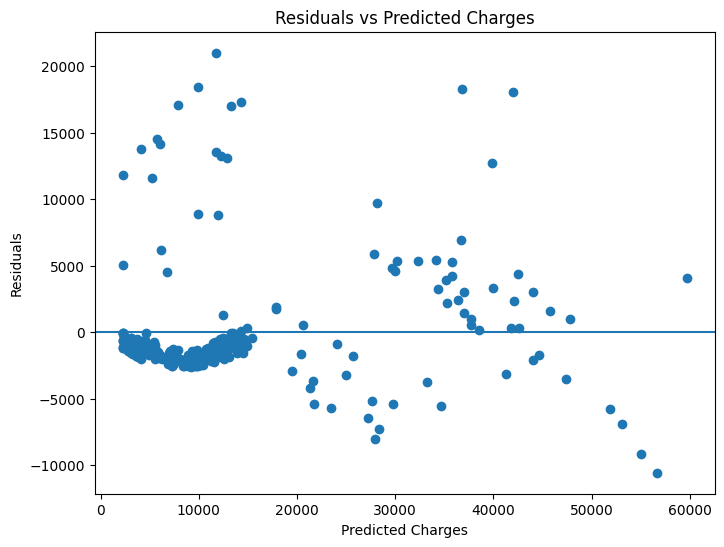

In [17]:
import matplotlib.pyplot as plt

residuals = y_test_i - y_pred_i

plt.figure(figsize= (8, 6))
plt.scatter(y_pred_i, residuals)
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Charges")
plt.axhline(0)
plt.show()

### Residual Analysis

The residual plot  shows that prediction errors are generally centered around zero, indicating no strong systematic bias.

However, the spread of  residuals increases for higher predicted charges, suggesting the presence of heteroscedasticity. This means the model tends to make larger errors for high-cost cases, likely among smokers with high BMI.

Overall, the model performs well for average insurance costs but is less precise for extreme cases.